# Final Project: When Are Umbrellas Actually Useful in Chicago?

## Introduction and Target Audience

As someone relatively new to Chicago, I wanted to understand when an umbrella is actually useful, not just when the weather is generally bad. My midterm project showed that umbrellas are surprisingly limited in Chicago because many hours have no precipitation, and many bad-weather periods involve wind or snow that reduce umbrella usefulness.

For the final project, I extend that analysis by exploring umbrella-favorable weather conditions more deeply over time. I also plan to compare those weather-based conditions against public attention using Google Trends data.

The target audience for this analysis is a Chicago resident deciding when an umbrella is worth carrying. A secondary audience is a retailer or marketer interested in whether public umbrella-related attention aligns with actual weather conditions.

The main research question is:

**When are umbrellas actually useful in Chicago, and does public attention toward umbrellas align with objectively favorable umbrella conditions?**

In [1]:
# Import core libraries
import requests
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import sqlite3

# Modeling libraries
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from sklearn.metrics import accuracy_score, precision_score, recall_score, confusion_matrix

## Data Source 1: Historical Chicago Weather Data

The anchor dataset for this project is hourly historical weather data from the Open-Meteo API. This is the same source used in my midterm project, but the final project expands the analysis with more time-series exploration.

The weather variables used are:

- Temperature
- Precipitation
- Wind speed

These variables are used to define when an umbrella is practically useful. Rain alone is not enough. An umbrella is most useful when there is rain, the temperature is above freezing, and wind is not too strong.

In [2]:
# Pull hourly historical weather data from Open-Meteo API

url = "https://archive-api.open-meteo.com/v1/archive"

params = {
    "latitude": 41.8781,
    "longitude": -87.6298,
    "start_date": "2023-04-01",
    "end_date": "2026-03-31",
    "hourly": "temperature_2m,precipitation,wind_speed_10m",
    "temperature_unit": "fahrenheit",
    "wind_speed_unit": "mph",
    "precipitation_unit": "inch",
    "timezone": "America/Chicago"
}

response = requests.get(url, params=params)

response.status_code

200

In [3]:
# Convert API response into a DataFrame

data = response.json()

weather_df = pd.DataFrame(data["hourly"])

weather_df.head()

,time,temperature_2m,precipitation,wind_speed_10m
0,2023-04-01T00:00,53.1,0.0,21.7
1,2023-04-01T01:00,49.2,0.0,22.4
2,2023-04-01T02:00,46.0,0.0,17.6
3,2023-04-01T03:00,43.8,0.0,15.5
4,2023-04-01T04:00,42.6,0.0,14.8


In [4]:
# Check size of dataset

weather_df.shape

(26304, 4)

In [5]:
# Check data types and missing values

weather_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 26304 entries, 0 to 26303
Data columns (total 4 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   time            26304 non-null  str    
 1   temperature_2m  26304 non-null  float64
 2   precipitation   26304 non-null  float64
 3   wind_speed_10m  26304 non-null  float64
dtypes: float64(3), str(1)
memory usage: 1.2 MB


In [6]:
# Summary statistics for numeric weather variables

weather_df.describe()

,temperature_2m,precipitation,wind_speed_10m
count,26304.000000,26304.000000,26304.00000
mean,51.890374,0.004547,9.19129
std,19.483381,0.028015,4.39610
min,-12.700000,0.000000,0.00000
25%,37.200000,0.000000,6.00000
50%,53.200000,0.000000,8.60000
75%,67.600000,0.000000,11.90000
max,98.600000,1.323000,28.10000


## Initial Data Review

The initial review checks the size, structure, data types, and summary statistics of the weather dataset. This is important before creating umbrella-related features because the final analysis depends on the validity of the temperature, precipitation, and wind speed variables.

In [7]:
# Convert time column to datetime format

weather_df["time"] = pd.to_datetime(weather_df["time"])

# Create time-based columns
weather_df["date"] = weather_df["time"].dt.date
weather_df["year"] = weather_df["time"].dt.year
weather_df["month"] = weather_df["time"].dt.month
weather_df["day"] = weather_df["time"].dt.day
weather_df["hour"] = weather_df["time"].dt.hour
weather_df["day_name"] = weather_df["time"].dt.day_name()

weather_df.head()

,time,temperature_2m,precipitation,wind_speed_10m,date,year,month,day,hour,day_name
0,2023-04-01 00:00:00,53.1,0.0,21.7,2023-04-01,2023,4,1,0,Saturday
1,2023-04-01 01:00:00,49.2,0.0,22.4,2023-04-01,2023,4,1,1,Saturday
2,2023-04-01 02:00:00,46.0,0.0,17.6,2023-04-01,2023,4,1,2,Saturday
3,2023-04-01 03:00:00,43.8,0.0,15.5,2023-04-01,2023,4,1,3,Saturday
4,2023-04-01 04:00:00,42.6,0.0,14.8,2023-04-01,2023,4,1,4,Saturday


In [8]:
# Create season column

def assign_season(month):
    if month in [12, 1, 2]:
        return "Winter"
    elif month in [3, 4, 5]:
        return "Spring"
    elif month in [6, 7, 8]:
        return "Summer"
    else:
        return "Fall"

weather_df["season"] = weather_df["month"].apply(assign_season)

weather_df[["time", "month", "season"]].head()

,time,month,season
0,2023-04-01 00:00:00,4,Spring
1,2023-04-01 01:00:00,4,Spring
2,2023-04-01 02:00:00,4,Spring
3,2023-04-01 03:00:00,4,Spring
4,2023-04-01 04:00:00,4,Spring


## Data Quality Checks

Before building the umbrella favorability framework, I check for common data quality issues:

- Missing values
- Duplicate rows
- Negative precipitation
- Negative wind speed
- Unusual values in the main weather variables

These checks help confirm that the data is reasonable for analysis.

In [9]:
# Check missing values

weather_df.isna().sum()

time              0
temperature_2m    0
precipitation     0
wind_speed_10m    0
date              0
year              0
month             0
day               0
hour              0
day_name          0
season            0
dtype: int64

In [10]:
# Check duplicate rows

weather_df.duplicated().sum()

np.int64(0)

In [11]:
# Check for negative wind speed

weather_df[weather_df["wind_speed_10m"] < 0]

,time,temperature_2m,precipitation,wind_speed_10m,date,year,month,day,hour,day_name,season


In [12]:
# Check extreme values

weather_df[["temperature_2m", "precipitation", "wind_speed_10m"]].describe(percentiles=[0.01, 0.05, 0.25, 0.5, 0.75, 0.95, 0.99])

,temperature_2m,precipitation,wind_speed_10m
count,26304.000000,26304.000000,26304.00000
mean,51.890374,0.004547,9.19129
std,19.483381,0.028015,4.39610
min,-12.700000,0.000000,0.00000
1%,3.200000,0.000000,1.40000
5%,19.100000,0.000000,2.90000
25%,37.200000,0.000000,6.00000
50%,53.200000,0.000000,8.60000
75%,67.600000,0.000000,11.90000
95%,80.100000,0.020000,17.20000


## Feature Engineering: Umbrella Favorability

The main feature engineering task is to define when an umbrella is actually useful.

The logic follows my midterm framework:

- Rain is precipitation when temperature is above freezing.
- Snow is precipitation when temperature is at or below freezing.
- High wind reduces umbrella usefulness.
- Heavy precipitation increases umbrella usefulness if wind is not too strong.
- Active hours are defined as 8 AM to 10 PM because umbrella usefulness matters more when people are likely to be outside.

In [13]:
# Basic precipitation flags

weather_df["precip_flag"] = weather_df["precipitation"] > 0

weather_df["rain_flag"] = (
    (weather_df["precipitation"] > 0) &
    (weather_df["temperature_2m"] > 32)
)

weather_df["snow_flag"] = (
    (weather_df["precipitation"] > 0) &
    (weather_df["temperature_2m"] <= 32)
)

weather_df[["time", "temperature_2m", "precipitation", "rain_flag", "snow_flag"]].head()

,time,temperature_2m,precipitation,rain_flag,snow_flag
0,2023-04-01 00:00:00,53.1,0.0,False,False
1,2023-04-01 01:00:00,49.2,0.0,False,False
2,2023-04-01 02:00:00,46.0,0.0,False,False
3,2023-04-01 03:00:00,43.8,0.0,False,False
4,2023-04-01 04:00:00,42.6,0.0,False,False


In [14]:
# Define high wind threshold using the 75th percentile

wind_threshold = weather_df["wind_speed_10m"].quantile(0.75)

weather_df["high_wind_flag"] = weather_df["wind_speed_10m"] > wind_threshold

wind_threshold

np.float64(11.9)

In [15]:
# Define heavy precipitation threshold using only positive precipitation hours

positive_precip = weather_df[weather_df["precipitation"] > 0]["precipitation"]

heavy_precip_threshold = positive_precip.quantile(0.75)

weather_df["heavy_precip_flag"] = weather_df["precipitation"] > heavy_precip_threshold

heavy_precip_threshold

np.float64(0.031)

In [16]:
# Define umbrella usefulness categories

weather_df["umbrella_high_value"] = (
    weather_df["rain_flag"] &
    weather_df["heavy_precip_flag"] &
    (~weather_df["high_wind_flag"])
)

weather_df["umbrella_medium_value"] = (
    weather_df["rain_flag"] &
    (~weather_df["heavy_precip_flag"]) &
    (~weather_df["high_wind_flag"])
)

weather_df["umbrella_low_value_or_bad"] = (
    weather_df["snow_flag"] |
    (weather_df["rain_flag"] & weather_df["high_wind_flag"])
)

weather_df[[
    "time",
    "rain_flag",
    "snow_flag",
    "high_wind_flag",
    "heavy_precip_flag",
    "umbrella_high_value",
    "umbrella_medium_value",
    "umbrella_low_value_or_bad"
]].head()

,time,rain_flag,snow_flag,high_wind_flag,heavy_precip_flag,umbrella_high_value,umbrella_medium_value,umbrella_low_value_or_bad
0,2023-04-01 00:00:00,False,False,True,False,False,False,False
1,2023-04-01 01:00:00,False,False,True,False,False,False,False
2,2023-04-01 02:00:00,False,False,True,False,False,False,False
3,2023-04-01 03:00:00,False,False,True,False,False,False,False
4,2023-04-01 04:00:00,False,False,True,False,False,False,False


In [17]:
# Define active hours

weather_df["active_hours_flag"] = weather_df["hour"].between(8, 22)

weather_df[["time", "hour", "active_hours_flag"]].head(24)

,time,hour,active_hours_flag
0,2023-04-01 00:00:00,0,False
1,2023-04-01 01:00:00,1,False
2,2023-04-01 02:00:00,2,False
3,2023-04-01 03:00:00,3,False
4,2023-04-01 04:00:00,4,False
5,2023-04-01 05:00:00,5,False
6,2023-04-01 06:00:00,6,False
7,2023-04-01 07:00:00,7,False
8,2023-04-01 08:00:00,8,True
9,2023-04-01 09:00:00,9,True


In [18]:
# Create umbrella value score

weather_df["umbrella_value_score"] = (
    weather_df["umbrella_high_value"].astype(int) * 3
    + weather_df["umbrella_medium_value"].astype(int) * 1
    - weather_df["umbrella_low_value_or_bad"].astype(int) * 1
)

# Set inactive hours to zero
weather_df.loc[~weather_df["active_hours_flag"], "umbrella_value_score"] = 0

weather_df[[
    "time",
    "temperature_2m",
    "precipitation",
    "wind_speed_10m",
    "active_hours_flag",
    "umbrella_value_score"
]].head(30)

,time,temperature_2m,precipitation,wind_speed_10m,active_hours_flag,umbrella_value_score
0,2023-04-01 00:00:00,53.1,0.000,21.7,False,0
1,2023-04-01 01:00:00,49.2,0.000,22.4,False,0
2,2023-04-01 02:00:00,46.0,0.000,17.6,False,0
3,2023-04-01 03:00:00,43.8,0.000,15.5,False,0
4,2023-04-01 04:00:00,42.6,0.000,14.8,False,0
5,2023-04-01 05:00:00,42.0,0.000,15.3,False,0
6,2023-04-01 06:00:00,41.6,0.008,15.4,False,0
7,2023-04-01 07:00:00,37.0,0.012,14.8,False,0
8,2023-04-01 08:00:00,37.0,0.008,17.1,True,-1
9,2023-04-01 09:00:00,37.2,0.012,19.0,True,-1


## Next Step

At this stage, the notebook has:

- Pulled historical Chicago weather data
- Created time-based variables
- Checked basic data quality
- Recreated and expanded the umbrella favorability framework from the midterm

The next section will aggregate the hourly data into daily, weekly, monthly, and seasonal views. This is where the final project begins to directly address the TA's feedback by adding more temporal and time-series analysis.

# Time-Series Analysis of Umbrella Favorability

The midterm analysis focused primarily on overall umbrella usefulness. For the final project, I expand the analysis by examining how umbrella-favorable conditions change over time.

Rather than looking only at individual hours, I aggregate the data into daily observations. This makes it possible to identify seasonal patterns, favorable periods, and longer-term trends that may not be visible at the hourly level.

The resulting daily dataset will also serve as the foundation for merging weather data with Google Trends data later in the analysis.

In [19]:
daily_weather = (
    weather_df
    .groupby("date")
    .agg({
        "umbrella_value_score": "sum",
        "precipitation": "sum",
        "temperature_2m": "mean",
        "wind_speed_10m": "mean",
        "umbrella_high_value": "sum",
        "umbrella_medium_value": "sum",
        "umbrella_low_value_or_bad": "sum"
    })
    .reset_index()
)

daily_weather.head()

,date,umbrella_value_score,precipitation,temperature_2m,wind_speed_10m,umbrella_high_value,umbrella_medium_value,umbrella_low_value_or_bad
0,2023-04-01,-5,0.052,40.216667,16.112500,0,0,7
1,2023-04-02,0,0.000,41.525000,10.845833,0,0,0
2,2023-04-03,0,0.352,46.641667,10.333333,1,1,4
3,2023-04-04,-3,0.446,51.825000,16.966667,0,1,8
4,2023-04-05,-4,0.709,59.795833,20.362500,0,0,7


In [20]:
daily_weather.shape

(1096, 8)

In [21]:
daily_weather["date"] = pd.to_datetime(daily_weather["date"])

daily_weather["year"] = daily_weather["date"].dt.year
daily_weather["month"] = daily_weather["date"].dt.month
daily_weather["day_name"] = daily_weather["date"].dt.day_name()

daily_weather.head()

,date,umbrella_value_score,precipitation,temperature_2m,wind_speed_10m,umbrella_high_value,umbrella_medium_value,umbrella_low_value_or_bad,year,month,day_name
0,2023-04-01,-5,0.052,40.216667,16.112500,0,0,7,2023,4,Saturday
1,2023-04-02,0,0.000,41.525000,10.845833,0,0,0,2023,4,Sunday
2,2023-04-03,0,0.352,46.641667,10.333333,1,1,4,2023,4,Monday
3,2023-04-04,-3,0.446,51.825000,16.966667,0,1,8,2023,4,Tuesday
4,2023-04-05,-4,0.709,59.795833,20.362500,0,0,7,2023,4,Wednesday


In [22]:
daily_weather["season"] = daily_weather["month"].apply(assign_season)

daily_weather.head()

,date,umbrella_value_score,precipitation,temperature_2m,wind_speed_10m,umbrella_high_value,umbrella_medium_value,umbrella_low_value_or_bad,year,month,day_name,season
0,2023-04-01,-5,0.052,40.216667,16.112500,0,0,7,2023,4,Saturday,Spring
1,2023-04-02,0,0.000,41.525000,10.845833,0,0,0,2023,4,Sunday,Spring
2,2023-04-03,0,0.352,46.641667,10.333333,1,1,4,2023,4,Monday,Spring
3,2023-04-04,-3,0.446,51.825000,16.966667,0,1,8,2023,4,Tuesday,Spring
4,2023-04-05,-4,0.709,59.795833,20.362500,0,0,7,2023,4,Wednesday,Spring


## Monthly Umbrella Favorability

The table below summarizes average umbrella favorability by month. If umbrella usefulness follows a seasonal pattern, certain months should consistently have higher average scores than others.

In [23]:
monthly_summary = (
    daily_weather
    .groupby("month")
    .agg({
        "umbrella_value_score": "mean",
        "precipitation": "mean"
    })
    .round(2)
)

monthly_summary

,umbrella_value_score,precipitation
month,,
1,-0.88,0.09
2,-0.54,0.03
3,1.06,0.13
4,-0.37,0.11
5,1.57,0.09
6,1.73,0.11
7,3.10,0.25
8,1.53,0.10
9,2.36,0.12


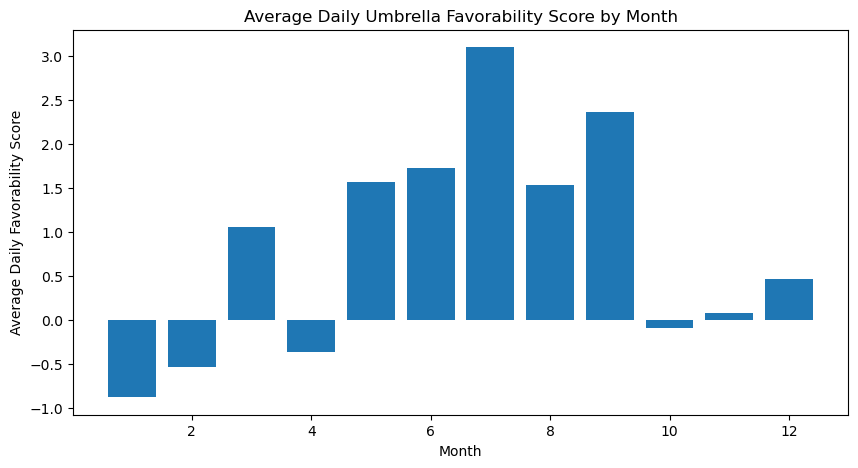

In [24]:
plt.figure(figsize=(10,5))

plt.bar(
    monthly_summary.index,
    monthly_summary["umbrella_value_score"]
)

plt.title("Average Daily Umbrella Favorability Score by Month")
plt.xlabel("Month")
plt.ylabel("Average Daily Favorability Score")

plt.show()

In [25]:
season_summary = (
    daily_weather
    .groupby("season")
    .agg({
        "umbrella_value_score": "mean",
        "precipitation": "mean"
    })
    .round(2)
)

season_summary

,umbrella_value_score,precipitation
season,,
Fall,0.77,0.10
Spring,0.77,0.11
Summer,2.12,0.15
Winter,-0.31,0.07


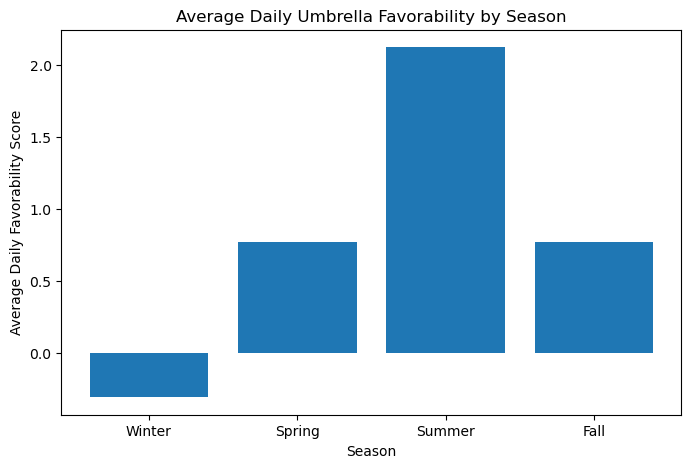

In [26]:
season_order = ["Winter", "Spring", "Summer", "Fall"]

season_plot = (
    season_summary
    .reindex(season_order)
)

plt.figure(figsize=(8,5))

plt.bar(
    season_plot.index,
    season_plot["umbrella_value_score"]
)

plt.title("Average Daily Umbrella Favorability by Season")
plt.xlabel("Season")
plt.ylabel("Average Daily Favorability Score")

plt.show()

## Rolling Average Analysis

Daily weather can be noisy. To better identify broader patterns, I calculate both 7-day and 30-day rolling averages of the umbrella favorability score.

Rolling averages help reveal sustained periods of favorable or unfavorable umbrella conditions.

In [27]:
daily_weather["rolling_7"] = (
    daily_weather["umbrella_value_score"]
    .rolling(window=7)
    .mean()
)

daily_weather["rolling_30"] = (
    daily_weather["umbrella_value_score"]
    .rolling(window=30)
    .mean()
)

daily_weather.head()

,date,umbrella_value_score,precipitation,temperature_2m,wind_speed_10m,umbrella_high_value,umbrella_medium_value,umbrella_low_value_or_bad,year,month,day_name,season,rolling_7,rolling_30
0,2023-04-01,-5,0.052,40.216667,16.112500,0,0,7,2023,4,Saturday,Spring,NaN,NaN
1,2023-04-02,0,0.000,41.525000,10.845833,0,0,0,2023,4,Sunday,Spring,NaN,NaN
2,2023-04-03,0,0.352,46.641667,10.333333,1,1,4,2023,4,Monday,Spring,NaN,NaN
3,2023-04-04,-3,0.446,51.825000,16.966667,0,1,8,2023,4,Tuesday,Spring,NaN,NaN
4,2023-04-05,-4,0.709,59.795833,20.362500,0,0,7,2023,4,Wednesday,Spring,NaN,NaN


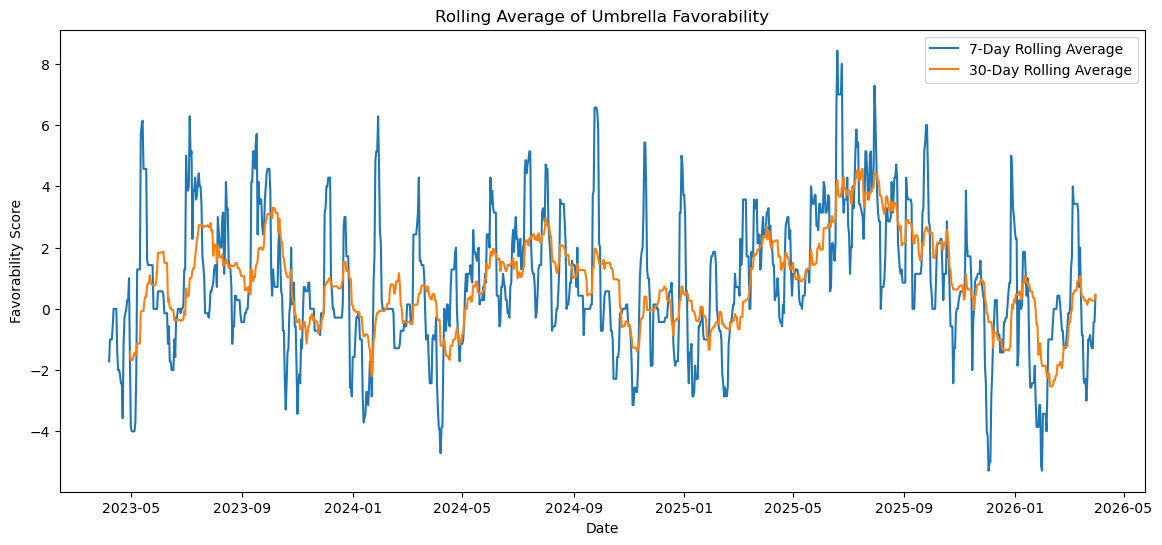

In [28]:
plt.figure(figsize=(14,6))

plt.plot(
    daily_weather["date"],
    daily_weather["rolling_7"],
    label="7-Day Rolling Average"
)

plt.plot(
    daily_weather["date"],
    daily_weather["rolling_30"],
    label="30-Day Rolling Average"
)

plt.title("Rolling Average of Umbrella Favorability")
plt.xlabel("Date")
plt.ylabel("Favorability Score")

plt.legend()

plt.show()

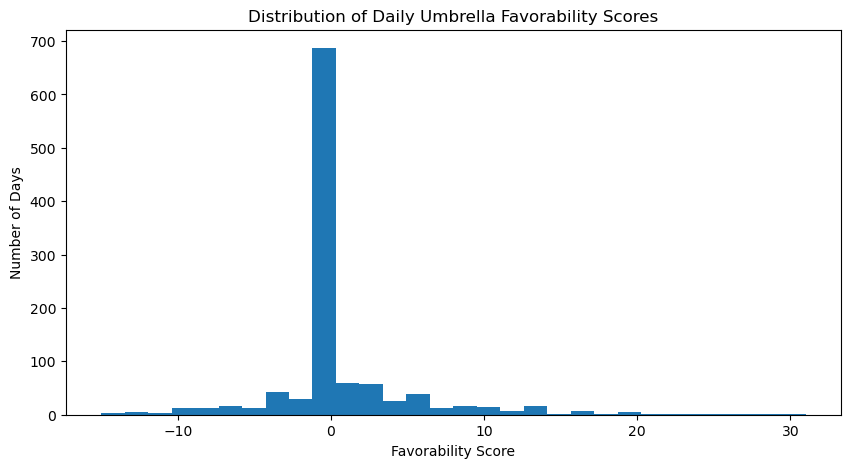

In [29]:
plt.figure(figsize=(10,5))

plt.hist(
    daily_weather["umbrella_value_score"],
    bins=30
)

plt.title("Distribution of Daily Umbrella Favorability Scores")
plt.xlabel("Favorability Score")
plt.ylabel("Number of Days")

plt.show()

## Monthly Heatmap Across Years

The monthly analysis identified substantial seasonality in umbrella favorability. However, monthly averages alone do not reveal whether those patterns are consistent across years.

To explore this question, I create a year-by-month heatmap. This visualization highlights how umbrella favorability changes over time and helps identify whether particularly favorable periods are recurring or unique to a specific year.

In [30]:
heatmap_data = (
    daily_weather
    .groupby(["year", "month"])
    ["umbrella_value_score"]
    .mean()
    .reset_index()
)

heatmap_data.head()

,year,month,umbrella_value_score
0,2023,4,-1.400000
1,2023,5,1.354839
2,2023,6,-0.200000
3,2023,7,2.516129
4,2023,8,1.129032


In [31]:
heatmap_pivot = heatmap_data.pivot(
    index="year",
    columns="month",
    values="umbrella_value_score"
)

heatmap_pivot

month,1,2,3,4,5,6,7,8,9,10,11,12
year,,,,,,,,,,,,
2023,NaN,NaN,NaN,-1.400000,1.354839,-0.200000,2.516129,1.129032,3.100000,-0.419355,-0.033333,0.870968
2024,-0.064516,-0.448276,0.451613,-1.033333,1.290323,1.533333,2.516129,1.387097,1.466667,-0.516129,0.100000,0.483871
2025,-0.677419,-0.714286,2.290323,1.333333,2.064516,3.866667,4.258065,2.064516,2.500000,0.677419,0.166667,0.032258
2026,-1.903226,-0.464286,0.451613,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


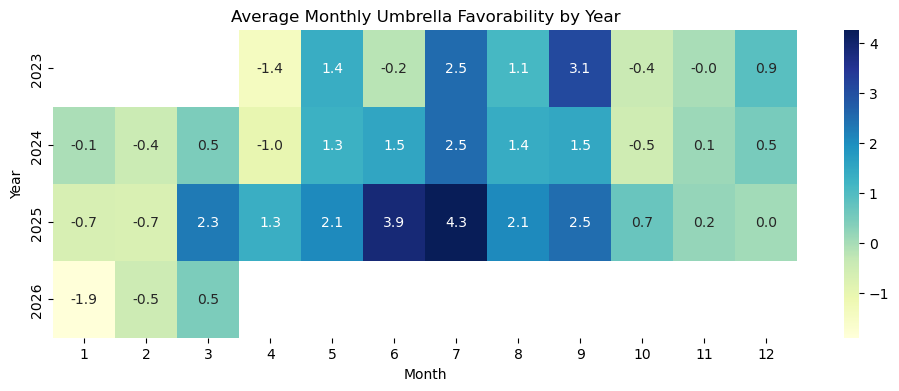

In [32]:
import seaborn as sns

plt.figure(figsize=(12,4))

sns.heatmap(
    heatmap_pivot,
    annot=True,
    fmt=".1f",
    cmap="YlGnBu"
)

plt.title("Average Monthly Umbrella Favorability by Year")

plt.xlabel("Month")
plt.ylabel("Year")

plt.show()

## Summary of Additional Time-Series Findings

The analyses above extend the midterm project by examining umbrella favorability across multiple temporal dimensions.

Specifically, the analysis explores:

- Variation by hour of day (Appendix)
- Differences between weekdays and weekends (Appendix)
- Consistency of seasonal patterns across multiple years

These perspectives provide a deeper understanding of when umbrella-favorable conditions occur and whether those conditions are predictable over time.

# Data Source 2: Google Trends

The weather analysis identified when umbrellas are objectively useful in Chicago. However, actual weather conditions do not necessarily reflect public perception.

To explore whether public attention aligns with umbrella-favorable weather conditions, I incorporate Google Trends data.

Google Trends does not measure purchases or umbrella usage directly. Instead, it measures relative search interest, which serves as a proxy for public attention and perceived need.

In [33]:
!pip install pytrends

Defaulting to user installation because normal site-packages is not writeable


In [34]:
from pytrends.request import TrendReq

In [35]:
pytrends = TrendReq(
    hl='en-US',
    tz=360
)

In [36]:
keyword = ["umbrella"]

pytrends.build_payload(
    keyword,
    timeframe='2023-04-01 2026-03-31',
    geo='US-IL'
)

In [37]:
trends_df = pytrends.interest_over_time()

trends_df.head()

,umbrella,isPartial
date,,
2023-03-26,21,False
2023-04-02,25,False
2023-04-09,35,False
2023-04-16,26,False
2023-04-23,29,False


In [38]:
trends_df.shape

(158, 2)

In [39]:
trends_df.tail()

,umbrella,isPartial
date,,
2026-03-01,25,False
2026-03-08,24,False
2026-03-15,25,False
2026-03-22,28,False
2026-03-29,40,False


## Initial Google Trends Review

Before combining the Google Trends data with weather observations, I examine the structure and quality of the search-interest data.

Key questions include:

- What level of time aggregation is available?
- Does the search interest vary meaningfully over time?
- Are there periods with missing or zero values?
- Is the dataset suitable for integration with the weather analysis?

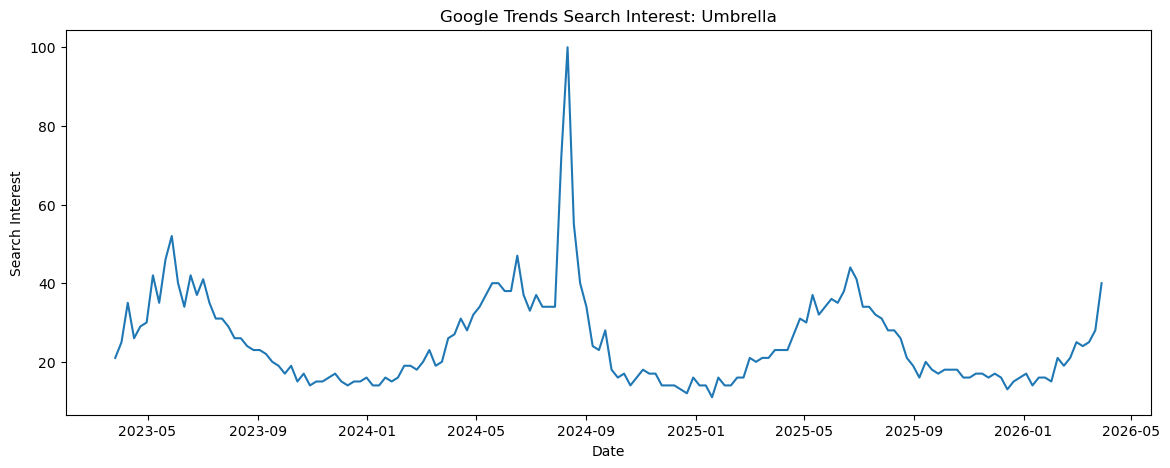

In [40]:
plt.figure(figsize=(14,5))

plt.plot(
    trends_df.index,
    trends_df["umbrella"]
)

plt.title("Google Trends Search Interest: Umbrella")
plt.xlabel("Date")
plt.ylabel("Search Interest")

plt.show()

## Google Trends Data Quality and Spike Review

The Google Trends series is weekly rather than daily. The values do not represent raw search counts. Instead, Google Trends reports relative search interest on a 0 to 100 scale, where 100 represents the highest-search week within the selected geography and time period.

Before merging this dataset with the weather data, I review the distribution of search interest and identify the highest-search weeks. This helps determine whether the data has enough variation to be useful in the analysis.

In [41]:
# Review summary statistics for Google Trends search interest

trends_df["umbrella"].describe()

count    158.000000
mean      25.101266
std       11.872566
min       11.000000
25%       16.000000
50%       21.000000
75%       32.000000
max      100.000000
Name: umbrella, dtype: float64

## Preparing Weekly Weather Data

Because Google Trends returned weekly search-interest data, the weather data also needs to be aggregated to the weekly level before the two datasets can be merged.

This aggregation converts the daily weather dataset into weekly observations using the same weekly date structure as Google Trends.

In [42]:
# Prepare daily weather date column for weekly aggregation

daily_weather["date"] = pd.to_datetime(daily_weather["date"])

# Create a week-start date aligned to Sunday, matching the Google Trends index
daily_weather["week_start"] = (
    daily_weather["date"] - pd.to_timedelta(daily_weather["date"].dt.dayofweek + 1, unit="D")
)

# If the date is already Sunday, the formula above moves it back one week.
# This line fixes Sundays so they remain their own week_start.
daily_weather.loc[
    daily_weather["date"].dt.day_name() == "Sunday",
    "week_start"
] = daily_weather["date"]

daily_weather[["date", "week_start", "umbrella_value_score"]].head(10)

,date,week_start,umbrella_value_score
0,2023-04-01,2023-03-26,-5
1,2023-04-02,2023-04-02,0
2,2023-04-03,2023-04-02,0
3,2023-04-04,2023-04-02,-3
4,2023-04-05,2023-04-02,-4
5,2023-04-06,2023-04-02,0
6,2023-04-07,2023-04-02,0
7,2023-04-08,2023-04-02,0
8,2023-04-09,2023-04-09,0
9,2023-04-10,2023-04-09,0


In [43]:
# Aggregate weather data to the weekly level

weekly_weather = (
    daily_weather
    .groupby("week_start")
    .agg({
        "umbrella_value_score": "sum",
        "precipitation": "sum",
        "temperature_2m": "mean",
        "wind_speed_10m": "mean",
        "umbrella_high_value": "sum",
        "umbrella_medium_value": "sum",
        "umbrella_low_value_or_bad": "sum"
    })
    .reset_index()
)

weekly_weather.head()

,week_start,umbrella_value_score,precipitation,temperature_2m,wind_speed_10m,umbrella_high_value,umbrella_medium_value,umbrella_low_value_or_bad
0,2023-03-26,-5,0.052,40.216667,16.112500,0,0,7
1,2023-04-02,-7,1.507,46.466667,12.539881,1,2,19
2,2023-04-09,0,0.032,61.539286,10.782143,0,3,1
3,2023-04-16,-25,0.704,47.992262,14.217262,1,4,43
4,2023-04-23,7,0.400,43.563095,8.724405,1,16,6


In [44]:
# Create additional weekly time variables

weekly_weather["year"] = weekly_weather["week_start"].dt.year
weekly_weather["month"] = weekly_weather["week_start"].dt.month
weekly_weather["season"] = weekly_weather["month"].apply(assign_season)

weekly_weather.head()

,week_start,umbrella_value_score,precipitation,temperature_2m,wind_speed_10m,umbrella_high_value,umbrella_medium_value,umbrella_low_value_or_bad,year,month,season
0,2023-03-26,-5,0.052,40.216667,16.112500,0,0,7,2023,3,Spring
1,2023-04-02,-7,1.507,46.466667,12.539881,1,2,19,2023,4,Spring
2,2023-04-09,0,0.032,61.539286,10.782143,0,3,1,2023,4,Spring
3,2023-04-16,-25,0.704,47.992262,14.217262,1,4,43,2023,4,Spring
4,2023-04-23,7,0.400,43.563095,8.724405,1,16,6,2023,4,Spring


## Cleaning Google Trends Data for Merge

The Google Trends dataframe uses its date as the index. To merge it with the weekly weather dataset, I reset the index and rename the date column to `week_start`.

I also remove the `isPartial` column because the returned data does not appear to include partial weeks.

In [45]:
# Clean Google Trends data for merging

trends_clean = (
    trends_df
    .reset_index()
    .rename(columns={"date": "week_start", "umbrella": "umbrella_search_interest"})
)

trends_clean["week_start"] = pd.to_datetime(trends_clean["week_start"])

# Drop isPartial if it exists
if "isPartial" in trends_clean.columns:
    trends_clean = trends_clean.drop(columns=["isPartial"])

trends_clean.head()

,week_start,umbrella_search_interest
0,2023-03-26,21
1,2023-04-02,25
2,2023-04-09,35
3,2023-04-16,26
4,2023-04-23,29


In [46]:
# Merge weekly weather data with Google Trends data

weekly_combined = pd.merge(
    weekly_weather,
    trends_clean,
    on="week_start",
    how="inner"
)

weekly_combined.head()

,week_start,umbrella_value_score,precipitation,temperature_2m,wind_speed_10m,umbrella_high_value,umbrella_medium_value,umbrella_low_value_or_bad,year,month,season,umbrella_search_interest
0,2023-03-26,-5,0.052,40.216667,16.112500,0,0,7,2023,3,Spring,21
1,2023-04-02,-7,1.507,46.466667,12.539881,1,2,19,2023,4,Spring,25
2,2023-04-09,0,0.032,61.539286,10.782143,0,3,1,2023,4,Spring,35
3,2023-04-16,-25,0.704,47.992262,14.217262,1,4,43,2023,4,Spring,26
4,2023-04-23,7,0.400,43.563095,8.724405,1,16,6,2023,4,Spring,29


In [47]:
# Check merged dataset size and missing values

weekly_combined.shape

(158, 12)

In [48]:
weekly_combined.isna().sum()

week_start                   0
umbrella_value_score         0
precipitation                0
temperature_2m               0
wind_speed_10m               0
umbrella_high_value          0
umbrella_medium_value        0
umbrella_low_value_or_bad    0
year                         0
month                        0
season                       0
umbrella_search_interest     0
dtype: int64

## Weather Favorability vs Public Search Interest

After merging the weather and Google Trends datasets, I compare weekly umbrella favorability with weekly umbrella search interest.

This helps evaluate whether public attention toward umbrellas rises during periods when weather conditions make umbrellas objectively more useful.

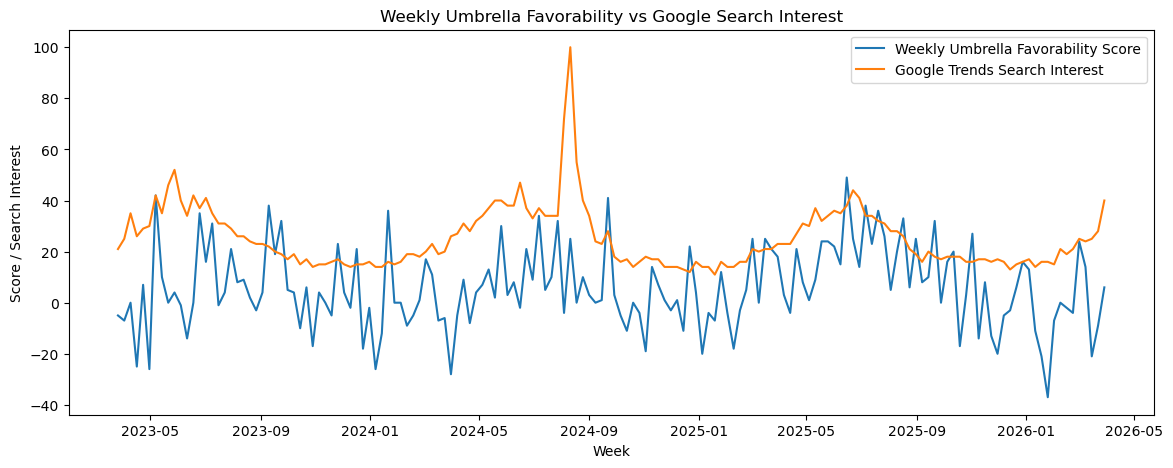

In [49]:
plt.figure(figsize=(14,5))

plt.plot(
    weekly_combined["week_start"],
    weekly_combined["umbrella_value_score"],
    label="Weekly Umbrella Favorability Score"
)

plt.plot(
    weekly_combined["week_start"],
    weekly_combined["umbrella_search_interest"],
    label="Google Trends Search Interest"
)

plt.title("Weekly Umbrella Favorability vs Google Search Interest")
plt.xlabel("Week")
plt.ylabel("Score / Search Interest")

plt.legend()

plt.show()

In [50]:
# Correlation between weekly favorability and search interest

correlation = weekly_combined[[
    "umbrella_value_score",
    "umbrella_search_interest"
]].corr()

correlation

,umbrella_value_score,umbrella_search_interest
umbrella_value_score,1.000000,0.296126
umbrella_search_interest,0.296126,1.000000


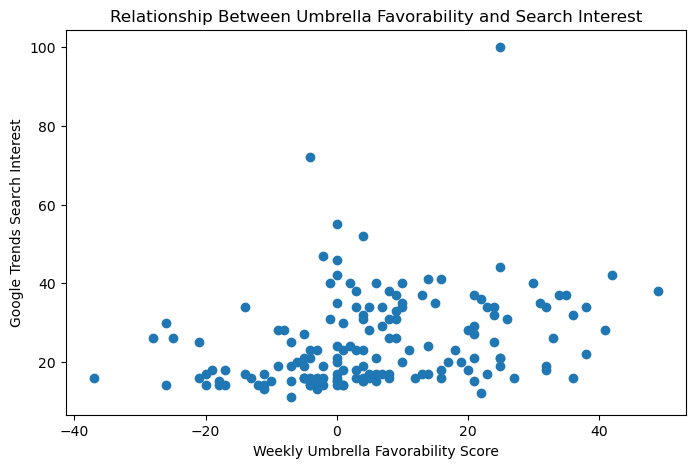

In [51]:
# Scatter plot to examine relationship more directly

plt.figure(figsize=(8,5))

plt.scatter(
    weekly_combined["umbrella_value_score"],
    weekly_combined["umbrella_search_interest"]
)

plt.title("Relationship Between Umbrella Favorability and Search Interest")
plt.xlabel("Weekly Umbrella Favorability Score")
plt.ylabel("Google Trends Search Interest")

plt.show()

In [52]:
# Identify weeks with highest search interest after merge

weekly_combined.sort_values(
    by="umbrella_search_interest",
    ascending=False
).head(10)

,week_start,umbrella_value_score,precipitation,temperature_2m,wind_speed_10m,umbrella_high_value,umbrella_medium_value,umbrella_low_value_or_bad,year,month,season,umbrella_search_interest
72,2024-08-11,25,1.871,72.355357,8.255357,8,14,6,2024,8,Summer,100
71,2024-08-04,-4,0.213,71.988095,10.092857,0,4,5,2024,8,Summer,72
73,2024-08-18,0,0.032,67.465476,8.748214,0,2,3,2024,8,Summer,55
9,2023-05-28,4,0.099,68.681548,7.737500,1,1,0,2023,5,Spring,52
64,2024-06-16,-2,0.198,80.821429,12.848810,1,2,8,2024,6,Summer,47
8,2023-05-21,0,0.000,59.173214,10.113095,0,0,0,2023,5,Spring,46
117,2025-06-22,25,0.873,80.360714,7.282143,5,17,2,2025,6,Summer,44
12,2023-06-18,0,0.000,69.905952,9.064286,0,0,0,2023,6,Summer,42
6,2023-05-07,42,1.281,56.523810,8.426190,13,16,6,2023,5,Spring,42
118,2025-06-29,14,0.525,79.892857,5.258929,2,8,0,2025,6,Summer,41


In [53]:
# Identify weeks with highest weather-based umbrella favorability

weekly_combined.sort_values(
    by="umbrella_value_score",
    ascending=False
).head(10)

,week_start,umbrella_value_score,precipitation,temperature_2m,wind_speed_10m,umbrella_high_value,umbrella_medium_value,umbrella_low_value_or_bad,year,month,season,umbrella_search_interest
116,2025-06-15,49,2.091,73.779762,6.950000,15,19,0,2025,6,Summer,38
6,2023-05-07,42,1.281,56.523810,8.426190,13,16,6,2023,5,Spring,42
78,2024-09-22,41,1.987,65.036905,11.570238,15,17,12,2024,9,Fall,28
119,2025-07-06,38,1.486,74.548810,5.979762,13,27,0,2025,7,Summer,34
24,2023-09-10,38,2.197,62.884524,6.844048,12,20,5,2023,9,Fall,22
43,2024-01-21,36,1.401,30.500000,8.437500,8,31,31,2024,1,Winter,16
121,2025-07-20,36,0.657,76.764881,6.314881,5,29,1,2025,7,Summer,32
13,2023-06-25,35,2.707,72.156548,9.422024,14,12,14,2023,6,Summer,37
67,2024-07-07,34,1.788,72.900000,7.286905,9,16,10,2024,7,Summer,37
125,2025-08-17,33,0.691,72.934524,6.499405,5,25,1,2025,8,Summer,26


## Weekly Analysis Findings

The weekly comparison revealed a positive but relatively modest correlation between umbrella favorability and Google search interest.

At first glance, the two time-series appear to move together. Both series generally increase during warmer months and decline during colder periods. However, the numerical correlation is weaker than expected.

One possible explanation is that weekly weather conditions are inherently noisy. Search behavior may not respond immediately to favorable umbrella conditions, and public attention may be influenced by unusual weather events rather than typical weekly patterns.

To better understand whether public attention aligns with broader weather conditions, I aggregate both datasets to the monthly level. Monthly aggregation reduces short-term volatility and makes it easier to identify longer-term seasonal relationships.

In [54]:
monthly_combined = (
    weekly_combined
    .groupby(["year", "month"])
    .agg({
        "umbrella_value_score": "mean",
        "umbrella_search_interest": "mean"
    })
    .reset_index()
)

monthly_combined.head()

,year,month,umbrella_value_score,umbrella_search_interest
0,2023,3,-5.0,21.00
1,2023,4,-10.2,29.00
2,2023,5,14.0,43.75
3,2023,6,5.0,38.25
4,2023,7,14.2,33.40


In [55]:
monthly_combined.shape

(37, 4)

## Monthly Weather Favorability vs Search Interest

Monthly aggregation smooths out week-to-week fluctuations and highlights broader seasonal patterns.

This analysis examines whether periods with higher average umbrella favorability also tend to exhibit higher average public search interest in umbrellas.

In [56]:
monthly_correlation = monthly_combined[[
    "umbrella_value_score",
    "umbrella_search_interest"
]].corr()

monthly_correlation

,umbrella_value_score,umbrella_search_interest
umbrella_value_score,1.000000,0.455274
umbrella_search_interest,0.455274,1.000000


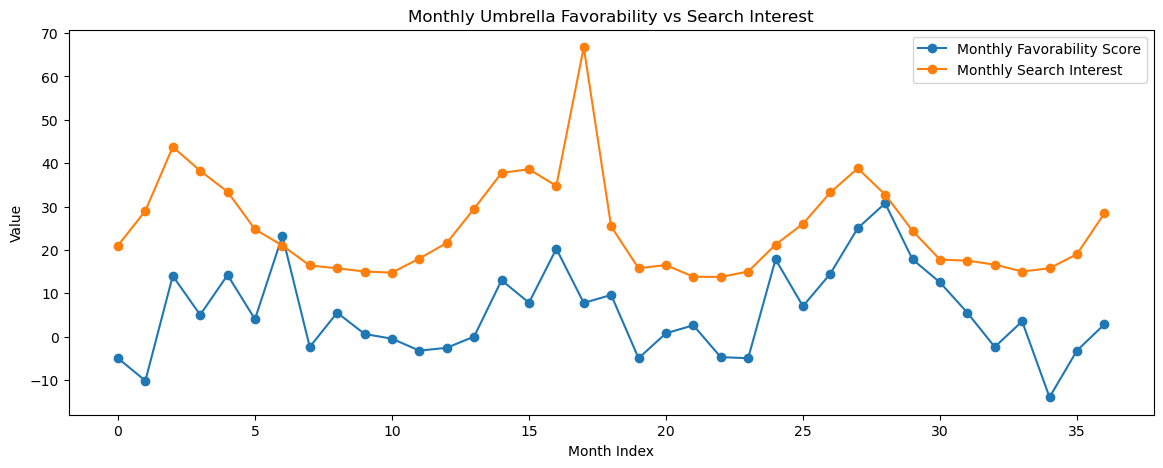

In [57]:
plt.figure(figsize=(14,5))

plt.plot(
    monthly_combined.index,
    monthly_combined["umbrella_value_score"],
    marker="o",
    label="Monthly Favorability Score"
)

plt.plot(
    monthly_combined.index,
    monthly_combined["umbrella_search_interest"],
    marker="o",
    label="Monthly Search Interest"
)

plt.title("Monthly Umbrella Favorability vs Search Interest")
plt.xlabel("Month Index")
plt.ylabel("Value")

plt.legend()

plt.show()

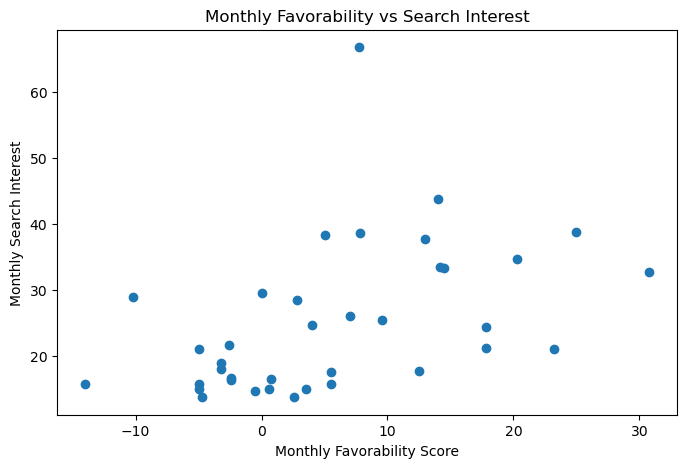

In [58]:
plt.figure(figsize=(8,5))

plt.scatter(
    monthly_combined["umbrella_value_score"],
    monthly_combined["umbrella_search_interest"]
)

plt.title("Monthly Favorability vs Search Interest")
plt.xlabel("Monthly Favorability Score")
plt.ylabel("Monthly Search Interest")

plt.show()

In [59]:
monthly_combined.sort_values(
    by="umbrella_search_interest",
    ascending=False
).head(10)

,year,month,umbrella_value_score,umbrella_search_interest
17,2024,8,7.75,66.75
2,2023,5,14.00,43.75
27,2025,6,25.00,38.80
15,2024,6,7.80,38.60
3,2023,6,5.00,38.25
14,2024,5,13.00,37.75
16,2024,7,20.25,34.75
4,2023,7,14.20,33.40
26,2025,5,14.50,33.25
28,2025,7,30.75,32.75


In [60]:
monthly_combined.sort_values(
    by="umbrella_value_score",
    ascending=False
).head(10)

,year,month,umbrella_value_score,umbrella_search_interest
28,2025,7,30.75,32.75
27,2025,6,25.00,38.80
6,2023,9,23.25,21.00
16,2024,7,20.25,34.75
29,2025,8,17.80,24.40
24,2025,3,17.80,21.20
26,2025,5,14.50,33.25
4,2023,7,14.20,33.40
2,2023,5,14.00,43.75
14,2024,5,13.00,37.75


### Monthly Analysis Findings

The monthly analysis revealed a stronger relationship between umbrella favorability and public search interest than the weekly analysis.

At the weekly level, the correlation between umbrella favorability and Google search interest was approximately 0.29. After aggregating both datasets to the monthly level, the correlation increased to approximately 0.45. This suggests that public attention toward umbrellas may respond more strongly to broader weather patterns than to short-term weather fluctuations.

The months with the highest umbrella search interest were generally concentrated between late spring and summer, which is also when umbrella favorability scores tended to be highest. However, the relationship was not perfect. For example, August 2024 recorded the highest search interest in the entire dataset despite only moderate umbrella favorability.

This suggests that while weather conditions influence public attention toward umbrellas, search behavior may also be affected by unusually visible weather events, media coverage, or other factors beyond average weather conditions.

Overall, the monthly results indicate that public attention aligns with umbrella-favorable weather conditions, but the relationship becomes clearer when weather is viewed over longer time horizons.

## Seasonal Weather Favorability vs Search Interest

The monthly analysis suggested that public attention toward umbrellas may respond more strongly to broader weather patterns than to individual weeks.

To further explore this possibility, I aggregate both umbrella favorability and Google search interest to the seasonal level.

If public perception is influenced primarily by general weather conditions rather than short-term fluctuations, the strongest alignment should appear at the seasonal level.

In [61]:
season_combined = (
    weekly_combined
    .groupby("season")
    .agg({
        "umbrella_value_score": "mean",
        "umbrella_search_interest": "mean"
    })
    .round(2)
)

season_combined

,umbrella_value_score,umbrella_search_interest
season,,
Fall,4.97,18.18
Spring,5.56,29.34
Summer,14.88,36.62
Winter,-2.45,15.50


## Seasonal Summary Table

The table below compares average umbrella favorability and average umbrella-related search interest across seasons.

This allows for a direct comparison between objectively favorable umbrella conditions and public attention.

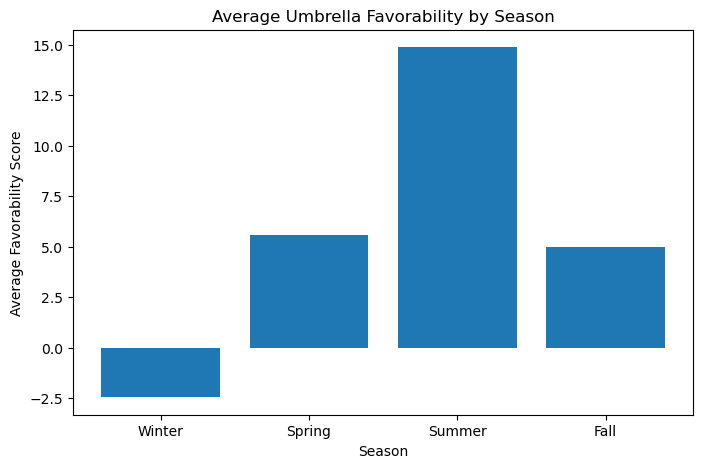

In [62]:
season_order = ["Winter", "Spring", "Summer", "Fall"]

season_plot = season_combined.reindex(season_order)

plt.figure(figsize=(8,5))

plt.bar(
    season_plot.index,
    season_plot["umbrella_value_score"]
)

plt.title("Average Umbrella Favorability by Season")
plt.xlabel("Season")
plt.ylabel("Average Favorability Score")

plt.show()

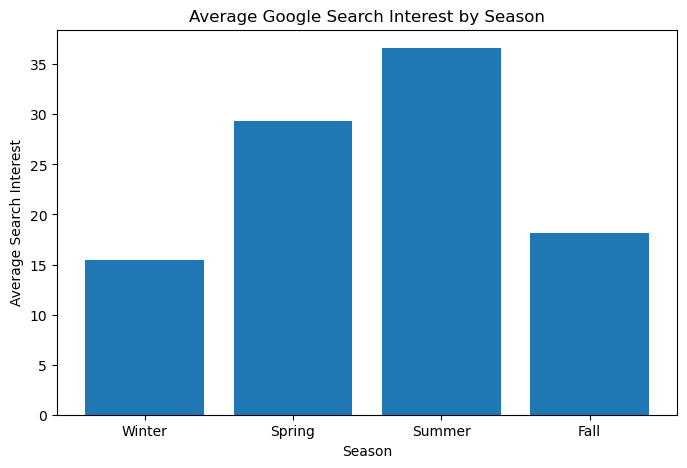

In [63]:
plt.figure(figsize=(8,5))

plt.bar(
    season_plot.index,
    season_plot["umbrella_search_interest"]
)

plt.title("Average Google Search Interest by Season")
plt.xlabel("Season")
plt.ylabel("Average Search Interest")

plt.show()

In [64]:
season_plot

,umbrella_value_score,umbrella_search_interest
season,,
Winter,-2.45,15.50
Spring,5.56,29.34
Summer,14.88,36.62
Fall,4.97,18.18


In [65]:
season_plot["favorability_rank"] = (
    season_plot["umbrella_value_score"]
    .rank(ascending=False)
)

season_plot["search_rank"] = (
    season_plot["umbrella_search_interest"]
    .rank(ascending=False)
)

season_plot

,umbrella_value_score,umbrella_search_interest,favorability_rank,search_rank
season,,,,
Winter,-2.45,15.50,4.0,4.0
Spring,5.56,29.34,2.0,2.0
Summer,14.88,36.62,1.0,1.0
Fall,4.97,18.18,3.0,3.0


### Seasonal Analysis Findings

The seasonal analysis produced the clearest evidence that public attention toward umbrellas aligns with broader weather patterns.

Summer had the highest average umbrella favorability score and also the highest average Google search interest. Winter ranked lowest on both measures. Spring and Fall occupied the middle positions. Remarkably, the seasonal rankings were identical across both datasets.

This result is stronger than the weekly and monthly findings because it demonstrates agreement not only in direction but also in ordering. While the magnitude of search interest did not perfectly match the magnitude of umbrella favorability, the public generally appeared to recognize which seasons were most favorable for umbrella use.

Taken together, the weekly, monthly, and seasonal analyses suggest that people do not respond strongly to individual weather weeks. Instead, public attention toward umbrellas appears to track broader seasonal weather cycles.

Chicago residents appear to recognize which seasons are generally favorable for umbrella use, but they do not precisely adjust their attention based on the exact level of umbrella usefulness.

# Regression Analysis

The previous analyses identified a positive relationship between umbrella favorability and Google search interest.

To quantify this relationship more formally, I estimate a series of regression models.

The first model examines whether weekly umbrella favorability can predict weekly umbrella-related search interest.

In [66]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

In [67]:
# Define X and y

X_weekly = weekly_combined[["umbrella_value_score"]]

y_weekly = weekly_combined["umbrella_search_interest"]

In [68]:
# Fit model

weekly_model = LinearRegression()

weekly_model.fit(X_weekly, y_weekly)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [69]:
# Predictions

weekly_pred = weekly_model.predict(X_weekly)

In [70]:
# R-squared

weekly_r2 = r2_score(
    y_weekly,
    weekly_pred
)

weekly_r2

0.08769050381746724

In [71]:
print("Intercept:", weekly_model.intercept_)
print("Coefficient:", weekly_model.coef_[0])
print("R-squared:", weekly_r2)

Intercept: 23.808588957055214
Coefficient: 0.22104214803601305
R-squared: 0.08769050381746724


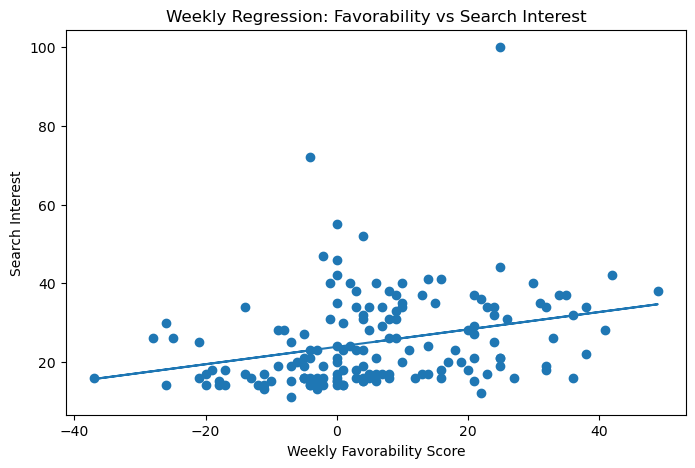

In [72]:
plt.figure(figsize=(8,5))

plt.scatter(
    X_weekly,
    y_weekly
)

plt.plot(
    X_weekly,
    weekly_pred
)

plt.title("Weekly Regression: Favorability vs Search Interest")
plt.xlabel("Weekly Favorability Score")
plt.ylabel("Search Interest")

plt.show()

## Monthly Regression Model

The correlation analysis suggested that umbrella search behavior aligns more closely with monthly weather patterns than with weekly weather conditions.

To evaluate this possibility, I estimate a second regression model using monthly observations.

In [73]:
X_monthly = monthly_combined[["umbrella_value_score"]]

y_monthly = monthly_combined["umbrella_search_interest"]

In [74]:
monthly_model = LinearRegression()

monthly_model.fit(
    X_monthly,
    y_monthly
)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [75]:
monthly_pred = monthly_model.predict(
    X_monthly
)

In [76]:
monthly_r2 = r2_score(
    y_monthly,
    monthly_pred
)

monthly_r2

0.20727425927332788

In [77]:
print("Intercept:", monthly_model.intercept_)
print("Coefficient:", monthly_model.coef_[0])
print("R-squared:", monthly_r2)

Intercept: 22.24408891096984
Coefficient: 0.5000903442497142
R-squared: 0.20727425927332788


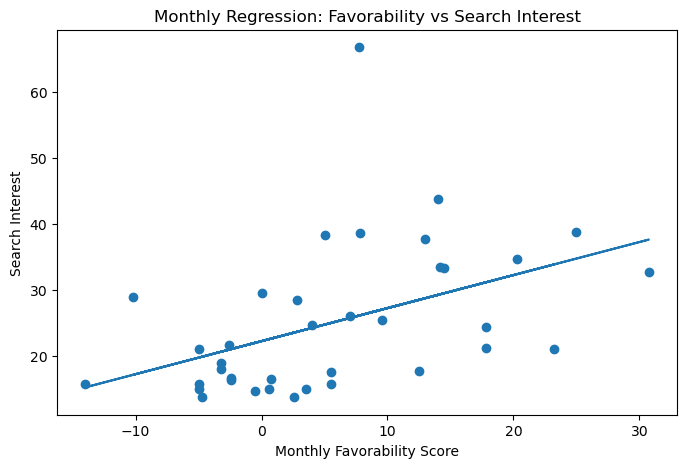

In [78]:
plt.figure(figsize=(8,5))

plt.scatter(
    X_monthly,
    y_monthly
)

plt.plot(
    X_monthly,
    monthly_pred
)

plt.title("Monthly Regression: Favorability vs Search Interest")
plt.xlabel("Monthly Favorability Score")
plt.ylabel("Search Interest")

plt.show()

### Regression Findings

The regression models provide additional evidence that public attention toward umbrellas is more closely related to broader weather patterns than short-term weather conditions.

The weekly regression model produced an R² of approximately 0.09, indicating that weekly umbrella favorability explains only a small portion of the variation in weekly Google search interest. Although the coefficient was positive, the overall predictive power of the model was limited.

The monthly regression model performed substantially better, producing an R² of approximately 0.21. This means that monthly umbrella favorability explained more than twice as much variation in search interest as the weekly model.

These findings are consistent with the correlation analysis. While umbrella-favorable weather conditions do influence public attention, the relationship becomes substantially stronger when weather is evaluated over broader time horizons.

The regression results therefore support the conclusion that umbrella-related search behavior is influenced by seasonal weather patterns rather than immediate week-to-week weather fluctuations.

# Final Conclusion

The goal of this project was to determine when umbrellas are actually useful in Chicago and whether public attention toward umbrellas aligns with objectively favorable weather conditions.

Using three years of hourly weather data from Open-Meteo, I developed an umbrella favorability framework based on precipitation type, precipitation intensity, wind conditions, and active outdoor hours. I then analyzed these conditions across multiple time horizons and compared them with Google Trends search interest for the term "umbrella" in Illinois.

Several findings emerged.

First, umbrella usefulness varies substantially throughout the year. Summer consistently produced the highest favorability scores, while winter produced the lowest. Favorable umbrella conditions were therefore not evenly distributed across time.

Second, public attention toward umbrellas generally follows the same broad seasonal patterns. Weekly weather conditions showed only a modest relationship with search behavior, but the relationship strengthened considerably when the data was aggregated to monthly and seasonal levels.

Third, the seasonal analysis produced nearly perfect alignment between weather-based umbrella favorability and public search interest. Summer ranked highest in both datasets, winter ranked lowest, and spring and fall occupied the middle positions. This suggests that Chicago residents generally recognize when umbrellas are most useful, even if they do not respond strongly to every individual weather event.

Overall, the results suggest that umbrella-related attention is influenced by weather conditions, but primarily through broader seasonal patterns rather than short-term fluctuations. In other words, people appear to think about umbrellas in terms of seasons rather than weeks.

For Chicago residents, the practical takeaway is that umbrellas are most valuable during late spring, summer, and early fall, while winter conditions often reduce their usefulness because precipitation is more likely to occur as snow or in conditions that make umbrellas less effective.

In [79]:
# Export cleaned datasets for separate SQL notebook

weather_df.to_csv("weather_hourly.csv", index=False)
daily_weather.to_csv("weather_daily.csv", index=False)
weekly_weather.to_csv("weather_weekly.csv", index=False)
trends_clean.to_csv("google_trends_weekly.csv", index=False)
weekly_combined.to_csv("weekly_combined.csv", index=False)
monthly_combined.to_csv("monthly_combined.csv", index=False)

# APPENDIX

## Hour-of-Day Analysis

The previous analyses showed that umbrella favorability varies across seasons and months. However, favorable weather conditions may also occur at specific times of day.

This analysis examines average umbrella favorability by hour to determine whether certain periods consistently produce more umbrella-friendly conditions.

Understanding the timing of favorable conditions can provide practical insight into when carrying an umbrella is most worthwhile.

In [80]:
hourly_summary = (
    weather_df
    .groupby("hour")
    .agg({
        "umbrella_value_score": "mean"
    })
    .round(2)
)

hourly_summary

,umbrella_value_score
hour,
0,0.00
1,0.00
2,0.00
3,0.00
4,0.00
5,0.00
6,0.00
7,0.00
8,0.11


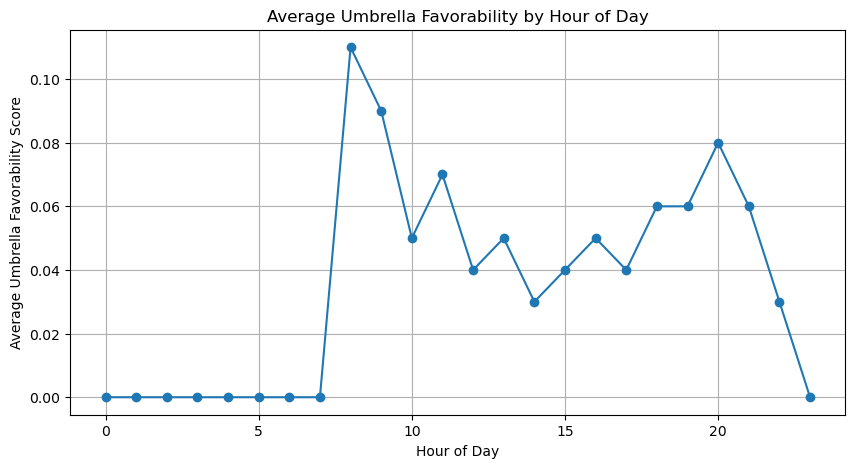

In [81]:
plt.figure(figsize=(10,5))

plt.plot(
    hourly_summary.index,
    hourly_summary["umbrella_value_score"],
    marker="o"
)

plt.title("Average Umbrella Favorability by Hour of Day")
plt.xlabel("Hour of Day")
plt.ylabel("Average Umbrella Favorability Score")

plt.grid(True)

plt.show()

In [82]:
top_hours = (
    hourly_summary
    .sort_values(
        by="umbrella_value_score",
        ascending=False
    )
    .head(5)
)

top_hours

,umbrella_value_score
hour,
8,0.11
9,0.09
20,0.08
11,0.07
21,0.06


## Weekday vs Weekend Analysis

Umbrella-favorable weather may not occur uniformly throughout the week. This analysis compares average umbrella favorability between weekdays and weekends.

While weather itself does not follow a work schedule, identifying differences may help determine whether favorable conditions disproportionately affect commuting periods or leisure activities.

In [83]:
# Create weekend flag using map

weather_df["is_weekend"] = weather_df["day_name"].map({
    "Monday": 0,
    "Tuesday": 0,
    "Wednesday": 0,
    "Thursday": 0,
    "Friday": 0,
    "Saturday": 1,
    "Sunday": 1
})

weather_df[["day_name", "is_weekend"]].head(10)

,day_name,is_weekend
0,Saturday,1
1,Saturday,1
2,Saturday,1
3,Saturday,1
4,Saturday,1
5,Saturday,1
6,Saturday,1
7,Saturday,1
8,Saturday,1
9,Saturday,1


In [84]:
daily_weather["day_type"] = np.where(
    daily_weather["day_name"].isin(["Saturday", "Sunday"]),
    "Weekend",
    "Weekday"
)

daily_weather.head()

,date,umbrella_value_score,precipitation,temperature_2m,wind_speed_10m,umbrella_high_value,umbrella_medium_value,umbrella_low_value_or_bad,year,month,day_name,season,rolling_7,rolling_30,week_start,day_type
0,2023-04-01,-5,0.052,40.216667,16.112500,0,0,7,2023,4,Saturday,Spring,NaN,NaN,2023-03-26,Weekend
1,2023-04-02,0,0.000,41.525000,10.845833,0,0,0,2023,4,Sunday,Spring,NaN,NaN,2023-04-02,Weekend
2,2023-04-03,0,0.352,46.641667,10.333333,1,1,4,2023,4,Monday,Spring,NaN,NaN,2023-04-02,Weekday
3,2023-04-04,-3,0.446,51.825000,16.966667,0,1,8,2023,4,Tuesday,Spring,NaN,NaN,2023-04-02,Weekday
4,2023-04-05,-4,0.709,59.795833,20.362500,0,0,7,2023,4,Wednesday,Spring,NaN,NaN,2023-04-02,Weekday


In [85]:
weekday_summary = (
    daily_weather
    .groupby("day_type")
    .agg({
        "umbrella_value_score": "mean",
        "precipitation": "mean"
    })
    .round(2)
)

weekday_summary

,umbrella_value_score,precipitation
day_type,,
Weekday,0.96,0.11
Weekend,0.56,0.12


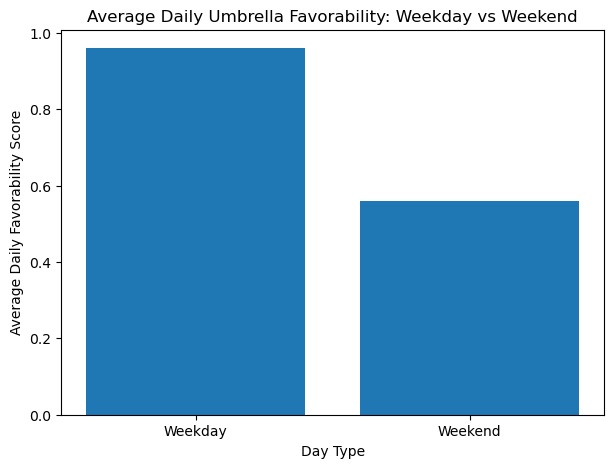

In [86]:
plt.figure(figsize=(7,5))

plt.bar(
    weekday_summary.index,
    weekday_summary["umbrella_value_score"]
)

plt.title("Average Daily Umbrella Favorability: Weekday vs Weekend")
plt.xlabel("Day Type")
plt.ylabel("Average Daily Favorability Score")

plt.show()